## Example:
Example workflow that loads a cropped z-stack from `examples` and reconstructs it by fitting the aberrations.

Fits the amplitude and phase of the aperture field, plus an ad hoc z-offset (which absorbs the
unknown offset between the nominal stack center and true best focus). An ad hoc z-scale parameter
is also included to absorb remaining index uncertainty or fudge factors with similar effects,
although it's expected to land near 1.

In [1]:
from pathlib import Path

import numpy as np
import tifffile
from tqdm.auto import tqdm

import torch
from torch.nn.parameter import Parameter
import torch.nn.functional as F
import torch.optim as optim

In [2]:
from beam_propagation.beam_propagator import BeamPropagator
from beam_propagation.forward_model import ForwardModel
from config import SimulationConfig, OpticalConfig, ZernikeConfig
from utilities.image_utilities import blur_1d, laplacian_variance
from utilities.visualization import plot_stack, plot_field

In [3]:
def load_example_image(image_path: str | Path, num_z: int, z_stride: int = 1) -> np.ndarray:
    stack = tifffile.imread(image_path)
    stack = stack[:, 1:, 1:]  # clumsy, patches are saved as 32x32, simulator wants (2^n - 1)x(2^n - 1)

    # Slice a smaller z-range around the focal plane
    lv = laplacian_variance(stack)
    lv = blur_1d(lv, sigma=2)
    z0 = np.argmax(lv)
    stack = stack[z0 - (num_z//2)*z_stride : z0 + (num_z//2)*z_stride + 1 : z_stride]

    # Roughly normalize
    stack = stack.astype(np.float64)
    stack = stack - stack.min((1, 2), keepdims=True)
    stack = stack / stack.sum((1, 2), keepdims=True)

    return stack

In [4]:
def make_object_distribution(
        object_grid_size: int,
        object_pixel_size: float,
        bead_diameter: float,
) -> torch.Tensor:
    x = torch.arange(-(object_grid_size//2), object_grid_size//2 + 1) * object_pixel_size
    y = torch.arange(-(object_grid_size//2), object_grid_size//2 + 1) * object_pixel_size
    Y, X = torch.meshgrid(y, x, indexing="ij")
    R = torch.sqrt(X*X + Y*Y)
    object_distrib = (R <= bead_diameter/2).float()
    return object_distrib

#### Simulation setup

In [5]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.08625  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.95
medium_index = 1.3744  # Dako embedding for the beads
immersion_index = 1.0  # air objective
dz = 0.120  # um, physical objective z-step
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 10  # max Zernike N
max_amplitude_order = 4  # max Zernike N
num_z = 11  # number of z-slices to fit, ~centered around the focal plane
z_stride = 2  # data will be sampled to this multiple of `dz`

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
sim_cfg = SimulationConfig(pupil_grid_size=pupil_grid_size, object_grid_size=object_grid_size, object_pixel_size=object_pixel_size)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(max_phase_order)
amp_cfg = ZernikeConfig(max_amplitude_order)

#### Data setup

In [7]:
image = load_example_image("../examples/bead_patch_01.tiff", num_z, z_stride)
image = torch.from_numpy(image).to(device)

z_idx = torch.arange(-(num_z//2), num_z//2 + 1, dtype=torch.float64, device=device)
z_objective = z_idx * dz * z_stride  # physical objective/stage positions, as reported by the microscope

object_distrib = make_object_distribution(object_grid_size, object_pixel_size, bead_diameter)
object_distrib = object_distrib.unsqueeze(0).expand((num_z, object_grid_size, object_grid_size))
object_distrib = object_distrib.to(device)

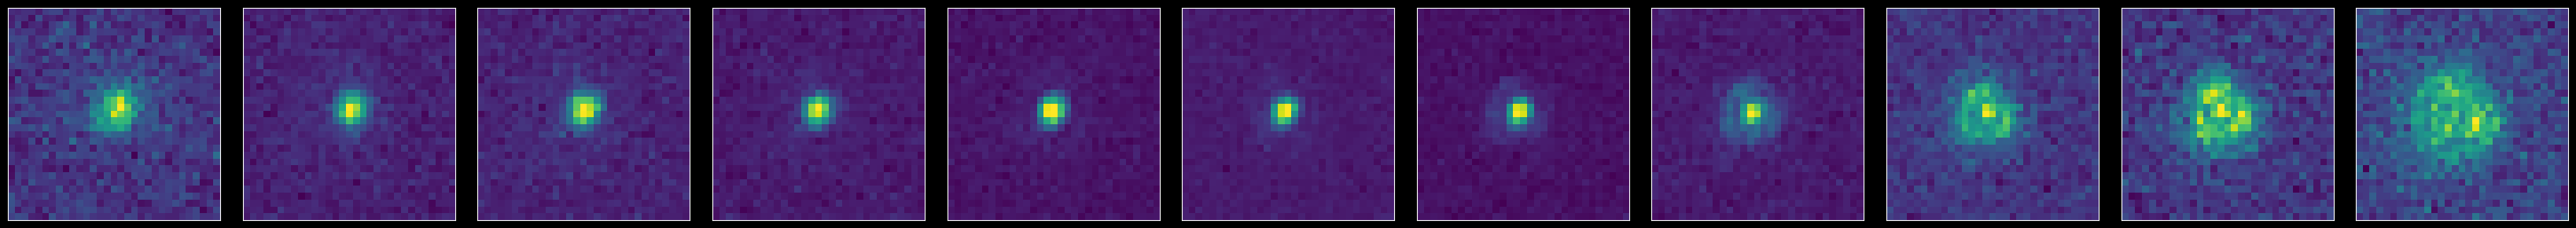

In [8]:
plot_stack(image.numpy(force=True))

#### Fit parameter setup

In [19]:
def get_calibrated_z(
        z_nominal: torch.Tensor,
        z_adjust_logit: Parameter,
        log_zscale: Parameter,
        z_adjust_max: float,
) -> torch.Tensor:
    """Scales and shifts the nominal z-positions by the learned parameters"""
    z = torch.exp(log_zscale) * z_nominal + z_adjust_max * torch.tanh(z_adjust_logit)
    return z

In [20]:
def apply_learned_normalization(
        image: torch.Tensor,
        bg_logit: Parameter,
        object_grid_size: int,
) -> torch.Tensor:
    """Normalizes the image stack using the learned background factor"""
    image = image / image.sum((1, 2), keepdim=True)
    bg = torch.sigmoid(bg_logit)
    return (1 - bg) * image + bg / (object_grid_size * object_grid_size)

In [21]:
z_adjust_logit = Parameter(torch.zeros((1,), dtype=torch.float32, device=device))  # handles global defocus
z_adjust_max = 0.5  # max fittable focus shift in either direction
log_zscale = Parameter(torch.zeros((1,), dtype=torch.float32, device=device))  # residual axial scale, exp(log_scale) should land near 1
bg_logit = Parameter(torch.zeros((num_z, 1, 1), dtype=torch.float64, device=device))  # handles per-z background

In [22]:
bp = BeamPropagator(sim_cfg, opt_cfg, phase_cfg, amp_cfg=amp_cfg)
model = ForwardModel(bp)
model = model.eval().to(device)

z_nominal = bp.defocus_from_objective_z(z_objective)  # rescale from physical objective positions to in-medium defocus propagation

In [23]:
torch.manual_seed(rng_seed)

init_phase_coefs = torch.randn((1, bp.num_phase_coefs), device=device) * 1e-3
phase_coefs = Parameter(init_phase_coefs.clone())

init_amp_coefs = torch.randn((1, bp.num_amp_coefs), device=device) * 1e-3
init_amp_coefs[:, 0] = 1.0  # bias towards a coherent spot
amp_coefs = Parameter(init_amp_coefs.clone())

#### Fitting

In [24]:
num_iters = 800
optimizer = optim.Adam(
    [phase_coefs, amp_coefs, z_adjust_logit, log_zscale, bg_logit],
    lr=1e-2,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_iters)

In [25]:
pbar = tqdm(range(num_iters))
for iter in pbar:
    z = get_calibrated_z(z_nominal, z_adjust_logit, log_zscale, z_adjust_max)
    pred = model(z, object_distrib, phase_coefs.expand(num_z, -1), amp_coefs.expand(num_z, -1))
    pred = apply_learned_normalization(pred, bg_logit, object_grid_size)

    loss = F.mse_loss(pred.sqrt(), image.sqrt())  # Poisson NLL would be better in principle, but this is similar for equalizing the variance

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if iter > 0:
        # eats an extra D2H sync to do this every iter, but not a big deal for this small example
        pbar.set_postfix(loss=loss.item())

  0%|          | 0/800 [00:00<?, ?it/s]

#### Viewing results

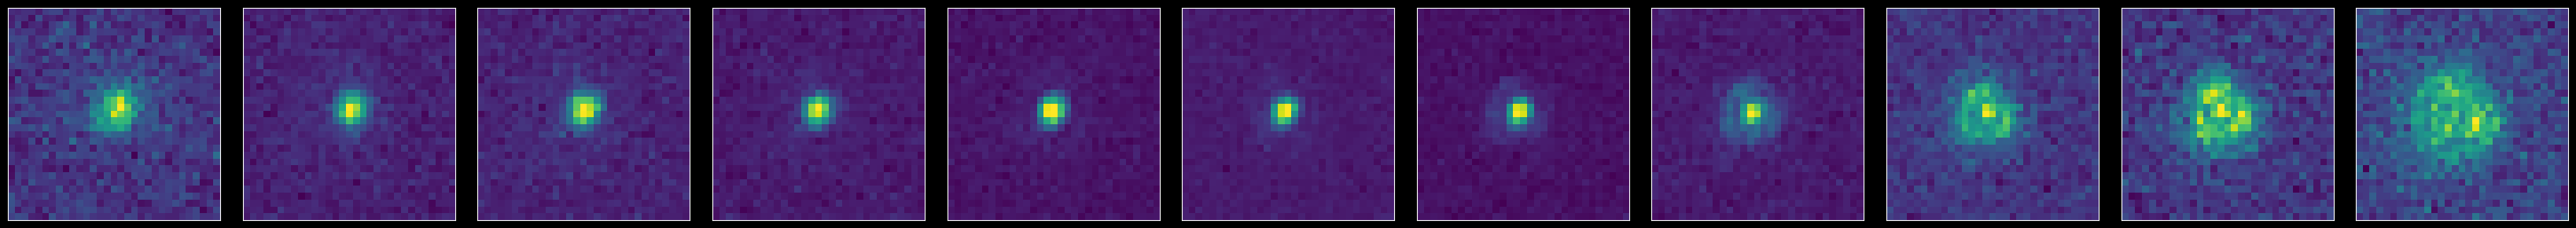

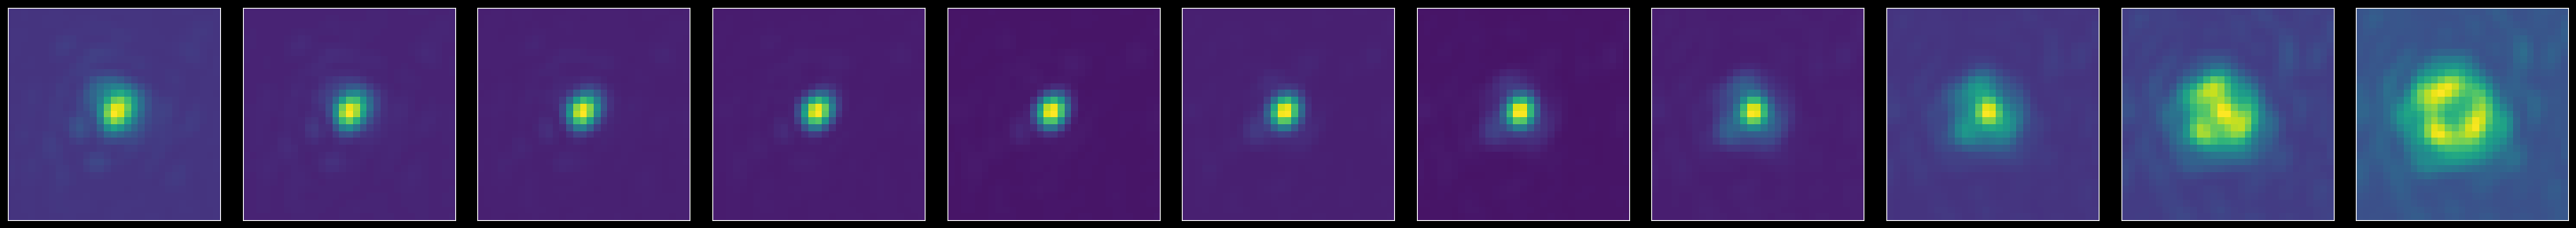

In [26]:
plot_stack(image.numpy(force=True))
plot_stack(pred.numpy(force=True))

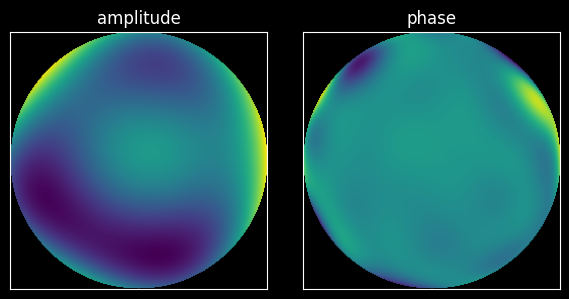

In [27]:
plot_field(bp, amp_coefs, phase_coefs)

In [28]:
print(f"fitted z-scale:  {torch.exp(log_zscale).item():.3f}")
print(f"fitted z-offset: {z_adjust_max * torch.tanh(z_adjust_logit).item():+.3f} um")

fitted z-scale:  0.990
fitted z-offset: +0.017 um
